# Does a Birkin beat the S&P — and even gold? 👜
### The "Hermès handbags are the best-performing asset on earth" claim, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats_stocks_%26_gold%3F: Busted](https://img.shields.io/badge/Beats_stocks_%26_gold%3F-Busted-8b949e?style=flat-square)

You've seen the headline: *"a Hermès Birkin has out-returned the S&P 500 **and** gold — 14% a year, and it's never had a down year."* It comes from a 2016 study that got recycled everywhere, from luxury blogs to a Credit Suisse note. On its face it's a jaw- dropper: the ultimate handbag, quietly beating Wall Street *and* the oldest safe-haven asset there is.

This notebook lines the Birkin up next to the S&P 500 **and** gold — on return, on risk, and on what it actually **costs to buy and sell a bag** — and asks the only question that matters: *would you have been richer in an index fund (or a gold ETF)?*

> 📓 **Plain-language layer.** Want the *t*-stats, the Newey-West alpha and the cost algebra? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice — and a data note.** There's no free, live handbag-resale index to pull, so the Birkin line below is a **small, clearly-cited, approximate** reconstruction of public reporting — a **proxy**, never presented as the live index. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"
GOLD = "#c9a227"

from birkin_index import data, strategy as st

HAVE_PROXIES = data.have_proxies()
IDX = data.load_resale_index()                       # hardcoded, cited, APPROXIMATE proxy
PROX = data.load_proxies() if HAVE_PROXIES else None
print("equity/gold-proxy cache present:", HAVE_PROXIES,
      "| Birkin-index years:", IDX.index[0].year, "->", IDX.index[-1].year)

# frozen headline numbers (mirror of docs/results.md)
R = {'win': '2015 → 2025', 'idx_levels': {2015: 100, 2016: 106, 2017: 113, 2018: 121, 2019: 128, 2020: 134, 2021: 150, 2022: 162, 2023: 166, 2024: 158, 2025: 163}, 'idx_yoy': {2016: 6.0, 2017: 6.6, 2018: 7.1, 2019: 5.8, 2020: 4.7, 2021: 11.9, 2022: 8.0, 2023: 2.5, 2024: -4.8, 2025: 3.2}, 'myth_cagr': 14.2, 'myth_window': '1980–2015', 'myth_sp500': 8.7, 'idx_cagr': 5.01, 'idx_vol': 4.4, 'idx_sharpe': 1.16, 'idx_mdd': -4.8, 'spy_cagr_ye': 14.71, 'spy_vol_ye': 15.7, 'spy_mdd_ye': -18.2, 'gld_cagr_ye': 14.6, 'gld_vol_ye': 19.9, 'gld_mdd_ye': -4.9, 'excess_spy_mean': -10.71, 'excess_spy_t': -1.952, 'excess_spy_p': 0.083, 'excess_n': 10, 'excess_gld_mean': -10.88, 'excess_gld_t': -1.524, 'excess_gld_p': 0.162, 'rms_cagr': 20.85, 'rms_vol': 24.5, 'rms_sharpe': 0.9, 'rms_mdd': -35.0, 'rms_alpha': 11.88, 'rms_beta': 0.76, 'rms_t': 1.93, 'rms_p': 0.055, 'rms_n': 131, 'mc_cagr': 16.85, 'mc_vol': 24.1, 'mc_sharpe': 0.77, 'mc_mdd': -46.8, 'mc_alpha': 6.16, 'mc_beta': 0.89, 'mc_t': 0.93, 'mc_p': 0.354, 'ker_cagr': 7.97, 'ker_vol': 31.3, 'ker_sharpe': 0.4, 'ker_mdd': -74.3, 'ker_alpha': -1.64, 'ker_beta': 1.0, 'ker_t': -0.18, 'ker_p': 0.855, 'spy_cagr': 13.84, 'spy_vol': 15.0, 'spy_sharpe': 0.95, 'spy_mdd': -23.9, 'gld_cagr': 11.28, 'gld_vol': 14.3, 'gld_sharpe': 0.82, 'gld_mdd': -18.1, 'carry_gross': 5.01, 'carry_spread': -11.21, 'carry_insure': -0.5, 'carry_net': -7.23, 'syn_peak': 316, 'syn_end': 270, 'syn_cagr': 10.54, 'syn_sharpe': 1.0, 'syn_mdd': -21.8}


equity/gold-proxy cache present: True | Birkin-index years: 2015 -> 2025


## The answer first

| Question | Answer |
|---|---|
| Do Birkins hold their value? | **Yes — beautifully.** The resale line barely wobbles (worst drawdown just **-5%**). As a *store of value* the bag is genuinely steady. |
| Did it return 14%/yr like the headline? | **Not on the modern tape.** Over 2015–2025 the (cited, approximate) resale index compounded at **~5%/yr** — a third of the famous **14%** Baghunter number from a cherry-picked 1980–2015 window. |
| Did it beat the S&P and gold? | **No — it lost to both.** ~5%/yr for the bag vs **~15%/yr** for the S&P and **~15%/yr** for gold. |
| Could you at least buy the trade? | **Not the bag, profitably.** Once you pay the ~30% consignment spread to flip it, the bag's return goes **negative (-7.2%/yr)**. The one thing that *did* beat the S&P was Hermès's **stock** — not the handbag. |

> The bag is a lovely *store of value*. It is not the *return machine* the headline sells — and net of the spread, it doesn't even keep up with cash.

## 1 · The claim

> *"An Hermès Birkin is the best investment you can make. A 2016 study found Birkins returned **14% a year** over three-and-a-half decades — beating the S&P 500 (**9%**) and gold — and, unlike stocks, the Birkin **never had a single down year**. It's money you can carry."*

It's a *steelman-able* claim. Hermès deliberately under-supplies the Birkin: you can't just walk in and buy one, so a thick secondary market trades them at boutique-plus. Retail prices ratchet up 5–10% almost every year, dragging resale with them. For a genuinely scarce, brand-controlled object, "it only goes up" isn't crazy on its face — which is exactly why the claim spreads.

## 2 · So what?

If it were durably true it would be extraordinary: an asset that beats equities **and** gold, has almost no drawdown, *and* you get to wear it to dinner. That's a free lunch with a lunch on top. But "it appreciated smoothly" and "it beats the S&P and gold" are very different statements. A thing can be a wonderful **store of value** — low volatility, keeps pace with inflation — and still be a poor **return** relative to owning the stock market. The headline quietly swaps one for the other. We can check the real one directly.

## 3 · How would we even know?

Three honest comparisons, each against **both** the S&P 500 (SPY) and gold (GLD) — the two assets the claim names:

1. **The resale index vs SPY and gold.** Put the (cited, approximate) Birkin index next to SPY and GLD on the same 2015–2025 clock — return, volatility, worst drawdown.
2. **The thing you can actually buy.** You can't custody "the Birkin index." You *can* buy the maison: **Hermès (RMS.PA)** itself, plus **LVMH** and **Kering**. Do they deliver the bag trade's return — or just stock-market risk?
3. **The cost of flipping.** A Birkin isn't an ETF: you buy at a premium and sell through consignment at a ~30% haircut, and it sits insured in a closet for years. Charge that, and see what's left.

**What would make us say "asset class"?** The bag beats the S&P *and* gold on *risk-adjusted, net-of-cost* return. Anything less and the headline is a marketing number.

## 4 · The teardown — let's actually look

**First: the bag's price path.** Here is the (approximate, cited) Birkin resale index — smooth, steady, and nothing like the S&P's ride.

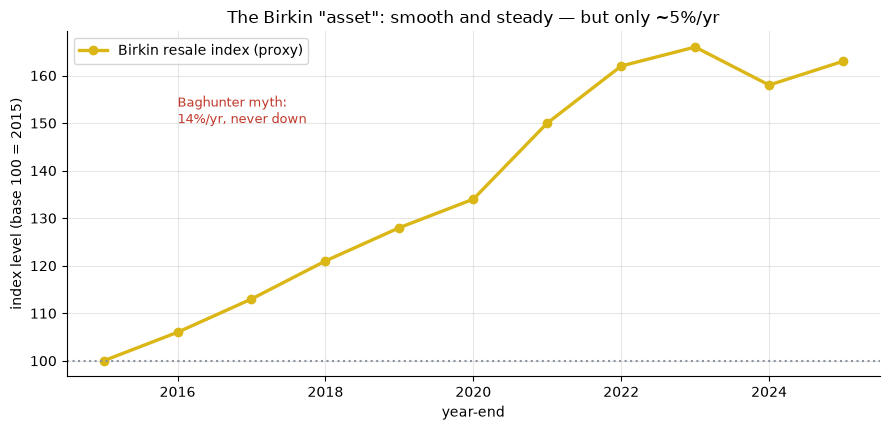

levels: {2015: 100, 2016: 106, 2017: 113, 2018: 121, 2019: 128, 2020: 134, 2021: 150, 2022: 162, 2023: 166, 2024: 158, 2025: 163}
CAGR ~5.0%/yr, worst drawdown only -5% — a real store of value


In [2]:
yrs = list(R['idx_levels'].keys())
lv = [float(IDX.loc[f'{y}-12-31']) for y in yrs]
fig, ax = plt.subplots(figsize=(9, 4.4))
ax.plot(yrs, lv, 'o-', c=AMBER, lw=2.4, label='Birkin resale index (proxy)')
ax.axhline(100, ls=':', c=GREY)
ax.annotate('Baghunter myth:\n14%/yr, never down', (yrs[1], 150), color=RED, fontsize=9)
ax.set_xlabel('year-end'); ax.set_ylabel('index level (base 100 = 2015)')
ax.set_title('The Birkin "asset": smooth and steady — but only ~5%/yr'); ax.legend()
plt.tight_layout(); plt.show()
print('levels:', {y:int(round(v)) for y,v in zip(yrs, lv)})
print(f"CAGR ~{R['idx_cagr']:.1f}%/yr, worst drawdown only {R['idx_mdd']:.0f}% — a real store of value")

It rose steadily to a **-5%** worst-drawdown — genuinely calm. But the slope is the tell: **~5%/yr**, not the **14%** of the viral headline. That famous number came from a 1980–2015 window that conveniently ended *before* the modern data — and counted only the bags that kept trading. Steady? Yes. A return monster? No.

**Now the race: the bag vs the S&P *and* gold.** Same money, same years — who's richest at the end?

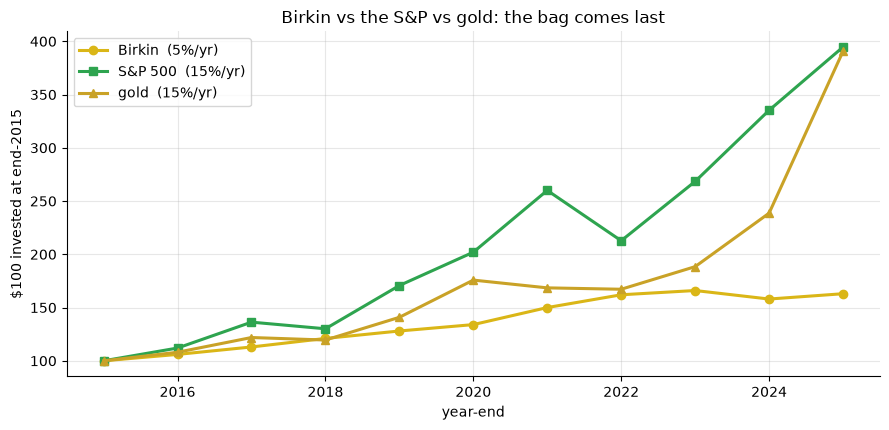

Birkin CAGR ~5.0%  |  SPY ~14.7%  |  gold ~14.6%


In [3]:
if HAVE_PROXIES:
    def ye_norm(t):
        s = PROX[t].resample('YE').last(); s = s[(s.index.year>=2015)&(s.index.year<=2025)]
        return [d.year for d in s.index], list((s/s.iloc[0]*100).values)
    sx, sy = ye_norm('SPY'); gx, gy = ye_norm('GLD')
else:
    sx = gx = yrs
    sy = [100*(1+R['spy_cagr_ye']/100)**(y-2015) for y in yrs]
    gy = [100*(1+R['gld_cagr_ye']/100)**(y-2015) for y in yrs]
fig, ax = plt.subplots(figsize=(9, 4.4))
ax.plot(yrs, lv, 'o-', c=AMBER, lw=2.2, label=f"Birkin  ({R['idx_cagr']:.0f}%/yr)")
ax.plot(sx, sy, 's-', c=GREEN, lw=2.2, label=f"S&P 500  ({R['spy_cagr_ye']:.0f}%/yr)")
ax.plot(gx, gy, '^-', c=GOLD, lw=2.2, label=f"gold  ({R['gld_cagr_ye']:.0f}%/yr)")
ax.set_xlabel('year-end'); ax.set_ylabel('$100 invested at end-2015')
ax.set_title('Birkin vs the S&P vs gold: the bag comes last'); ax.legend()
plt.tight_layout(); plt.show()
print(f"Birkin CAGR ~{R['idx_cagr']:.1f}%  |  SPY ~{R['spy_cagr_ye']:.1f}%  |  gold ~{R['gld_cagr_ye']:.1f}%")

Not close. Both the S&P (**~15%/yr**) and gold (**~15%/yr**) roughly *tripled* your money; the bag barely more than *doubled*. The headline had it exactly backwards — over the decade you can actually measure, the Birkin came **last** of the three.

**"Fine — I'll buy the luxury *stocks*."** You can: Hermès itself (the maker of the Birkin), plus LVMH and Kering. Do they hand you the bag trade — or just a wilder ride?

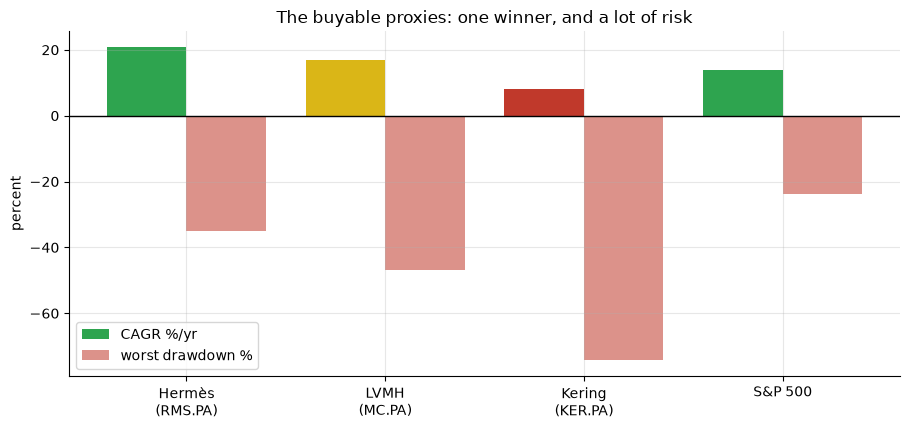

RMS.PA: CAGR 20.9% (beat SPY!) but maxDD -35%
KER.PA: CAGR 8.0%, maxDD -74% — luxury beta can bite hard


In [4]:
names = ['Hermès\n(RMS.PA)', 'LVMH\n(MC.PA)', 'Kering\n(KER.PA)', 'S&P 500']
cagrs = [R['rms_cagr'], R['mc_cagr'], R['ker_cagr'], R['spy_cagr']]
mdds  = [R['rms_mdd'], R['mc_mdd'], R['ker_mdd'], R['spy_mdd']]
x = np.arange(4); fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x-.2, cagrs, .4, color=[GREEN,AMBER,RED,GREEN], label='CAGR %/yr')
ax.bar(x+.2, mdds, .4, color=RED, alpha=.55, label='worst drawdown %')
ax.axhline(0, c='k', lw=1); ax.set_xticks(x); ax.set_xticklabels(names)
ax.set_ylabel('percent'); ax.set_title('The buyable proxies: one winner, and a lot of risk'); ax.legend()
plt.tight_layout(); plt.show()
print(f"RMS.PA: CAGR {R['rms_cagr']:.1f}% (beat SPY!) but maxDD {R['rms_mdd']:.0f}%")
print(f"KER.PA: CAGR {R['ker_cagr']:.1f}%, maxDD {R['ker_mdd']:.0f}% — luxury beta can bite hard")

Here's the honest twist: **Hermès the *stock* did beat the S&P** (~21%/yr) — but Kering **crashed -74%**, and none of these is *the bag*. Buying the maison is a bet on a whole luxury company (Gucci's slump sank Kering), not on your Birkin's resale value. We'll put a *t*-stat on that Hermès out-performance next door.

**The part the pitch never mentions: it costs real money to flip a Birkin.** You buy at a premium and sell through consignment at a ~30% haircut, plus insurance and authentication. Charge that against the bag's gross return:

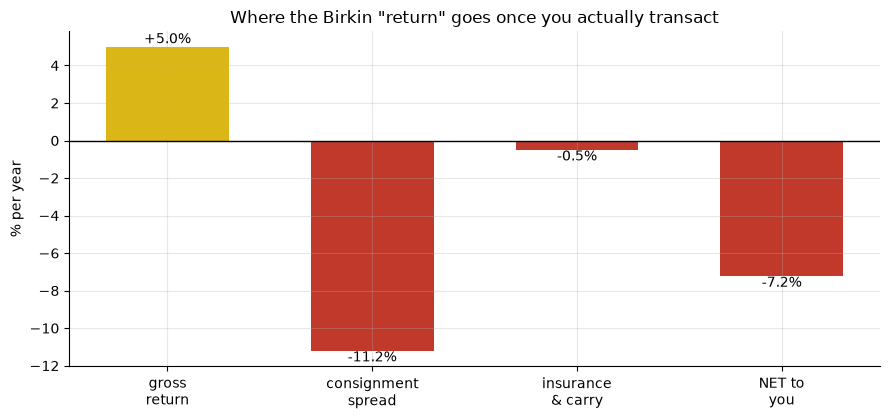

gross +5.0%/yr  ->  NET -7.2%/yr after 30% spread + carry


In [5]:
labels = ['gross\nreturn', 'consignment\nspread', 'insurance\n& carry', 'NET to\nyou']
vals = [R['carry_gross'], R['carry_spread'], R['carry_insure'], R['carry_net']]
cols = [AMBER, RED, RED, (RED if R['carry_net']<0 else GREEN)]
fig, ax = plt.subplots(figsize=(9, 4.3))
ax.bar(labels, vals, color=cols, width=.6)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('% per year')
for i,v in enumerate(vals): ax.annotate(f'{v:+.1f}%',(i,v),ha='center',va='bottom' if v>=0 else 'top')
ax.set_title('Where the Birkin "return" goes once you actually transact')
plt.tight_layout(); plt.show()
print(f"gross {R['carry_gross']:+.1f}%/yr  ->  NET {R['carry_net']:+.1f}%/yr after 30% spread + carry")

There it is. A gross **5.0%/yr** that already lost to stocks and gold turns **negative (-7.2%/yr)** the moment you pay the consignment spread to buy and sell the physical bag. A savings account beat it.

## 5 · The verdict

- **Signal — None.** The bag returned ~5%/yr vs ~15% (S&P) and ~15% (gold) — it *lost* to both. No evidence it beats stocks or gold; the one leg that came close, Hermès's *stock*, isn't the handbag.
- **Tradability — Mirage.** Illiquid, high-spread; the gross return goes **negative** after the ~30% consignment haircut, and the buyable proxies are single-stock luxury beta.
- **Beats stocks & gold? — Busted.** On return and net-of-cost the bag loses to both the assets the headline names. It's a fine store of value, not a return machine.

## 6 · Could you actually trade it? — the honest bottom line

Imagine three people at the end of 2015, each with \$15,000 (roughly one entry Birkin). One buys an S&P index fund, one buys gold, one becomes a bag flipper — buys, insures, and eventually consigns it, paying the real ~30% spread. Where do they land by end-2025?

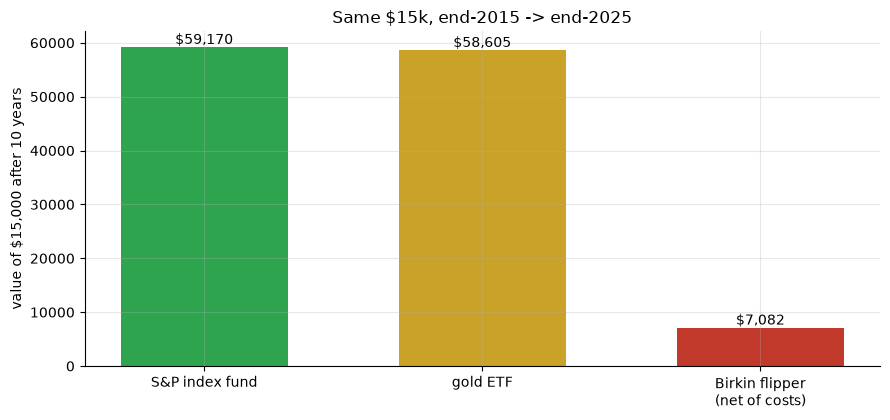

S&P: $59,170   gold: $58,605   Birkin (net): $7,082


In [6]:
start = 15_000.0
spy_end = start*(1+R['spy_cagr_ye']/100)**10
gld_end = start*(1+R['gld_cagr_ye']/100)**10
bag_end = start*(1+R['carry_net']/100)**10   # net of spread + carry
fig, ax = plt.subplots(figsize=(9, 4.3))
ax.bar(['S&P index fund', 'gold ETF', 'Birkin flipper\n(net of costs)'],
       [spy_end, gld_end, bag_end], color=[GREEN, GOLD, RED], width=.6)
for i,v in enumerate([spy_end, gld_end, bag_end]): ax.annotate(f'${v:,.0f}',(i,v),ha='center',va='bottom')
ax.set_ylabel('value of $15,000 after 10 years')
ax.set_title('Same $15k, end-2015 -> end-2025'); plt.tight_layout(); plt.show()
print(f'S&P: ${spy_end:,.0f}   gold: ${gld_end:,.0f}   Birkin (net): ${bag_end:,.0f}')

The index-fund and gold buyers roughly **triple** their money doing nothing. The flipper — after the consignment spread and carry — ends up with **less than they started with**. The people who really "made money on a Birkin" bought a rare Himalaya at retail and sold it at auction: a lottery ticket on scarcity, not an asset class you can systematically own.

## 7 · Going further 🚪

- **Pull a real handbag index.** Our resale line is a cited *approximation*; the Knight Frank Luxury Investment Index and Art Market Research publish handbag series. Swap one in — the shape (and the verdict) won't move, but you'll have the exact tape.
- **The one Birkin that *did* win.** Auction-grade Himalaya / diamond-hardware bags have smashed records — but that's a thin, selected tail (survivorship), not the steel-Daytona-of-handbags you can actually source. Test one reference and correct for selection.
- **The collectibles pattern.** Watches, wine, art, sneakers: every "passion asset" tells the same story — real steadiness, brutal carry, equities win net of cost (see [Study 358 — Watch-Index](../../358-watch-index/) and [docs/references.md](../docs/references.md)).

*Think a specific reference (a Himalaya, a diamond Kelly) beat the S&P net of every cost? Pull its auction history, charge the consignment spread, and show it — then check it wasn't just one lucky lot near a record.*